In [4]:
import os
import iris

hov_dir = '/scratch/iq82/fc6164/esmvaltool_output/recipe_template_20260120_225350/preproc/hovmoller_diagnostic'
# check baro
fp = '/scratch/iq82/fc6164/esmvaltool_output/recipe_template_20260120_044826/preproc/barotropic_streamfunction/sst_east/CMIP6_ACCESS-OM2_Omon_omip2_r1i1p1f1_umo_gn_0238-0246.nc'

In [5]:
all_files = []
for root, _, files in os.walk(hov_dir):
    for f in files:
        if f.endswith('.nc'):
            all_files.append(os.path.join(root, f))

all_files

['/scratch/iq82/fc6164/esmvaltool_output/recipe_template_20260120_225350/preproc/hovmoller_diagnostic/so_area/CMIP6_ACCESS-ESM1-5_Omon_historical_r1i1p1f1_so_gn_1850-2014.nc',
 '/scratch/iq82/fc6164/esmvaltool_output/recipe_template_20260120_225350/preproc/hovmoller_diagnostic/thetao/CMIP6_ACCESS-ESM1-5_Omon_historical_r1i1p1f1_thetao_gn_1850-2014.nc',
 '/scratch/iq82/fc6164/esmvaltool_output/recipe_template_20260120_225350/preproc/hovmoller_diagnostic/thetao_area/CMIP6_ACCESS-ESM1-5_Omon_historical_r1i1p1f1_thetao_gn_1850-2014.nc',
 '/scratch/iq82/fc6164/esmvaltool_output/recipe_template_20260120_225350/preproc/hovmoller_diagnostic/so/CMIP6_ACCESS-ESM1-5_Omon_historical_r1i1p1f1_so_gn_1850-2014.nc']

In [7]:
thetao = iris.load_cube(all_files[1]) # load area, area statistics - get area
ts_area = iris.load_cube(all_files[2])

In [12]:
from esmvalcore.preprocessor import area_statistics
from esmvalcore.preprocessor import anomalies
from esmvalcore.preprocessor import mask_landsea #add stof

def hovmoller(ds_load, startyr):
    cube = anomalies(ds_load, period='full', reference={'start_year':startyr, 'start_month':1,'start_day':1,
                                                            'end_year':startyr, 'end_month':12, 'end_day':31})
    # anomalies doesn't retain cell measure required for area statistics
    cube.add_cell_measure(ds_load.cell_measure('cell_area'), data_dims=[2,3])
    # sum anomalies
    cube = area_statistics(cube, operator='sum')

    #divide by total area cube (anomalies are summed.. weighted by cell_area(multiplied)
    tarea = totalarea_depth(ds_load)
    return cube / tarea

# vertical variation of total area
def totalarea_depth(cube):
    tmp1 = cube[0] #get first time step
    # divide by itself for 1s mask 3-dimensional
    tmp1.data = tmp1.data / tmp1.data
    # check cell_measure exists?
    if cube.cell_measure('cell_area'):
        return area_statistics(tmp1, operator='sum')



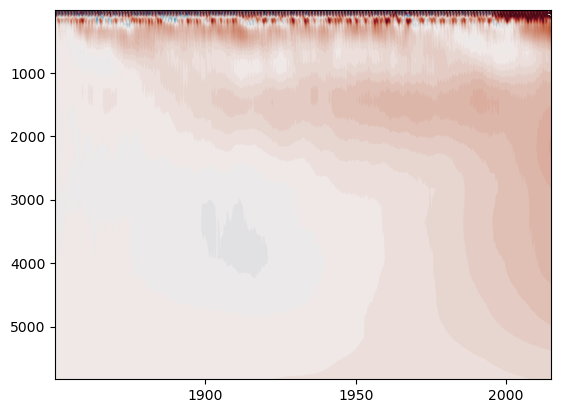

In [12]:
out = hovmoller(thetao, 1850)
out
import cmocean.cm as cm
import numpy as np
import iris.plot as iplt
levels_temperature = np.arange(-0.3, 0.31, 0.01)
iplt.contourf(out, levels = levels_temperature, cmap = cm.balance)

In [5]:
from esmvalcore.dataset import Dataset

temp_OM2 = Dataset(short_name='so', project='CMIP6',
    activity='OMIP', mip="Omon", exp="omip2",
    ensemble="r1i1p1f1", timerange="*",
    dataset="ACCESS-OM2", grid="gn")

# add ancillary
# temp_OM2.add_supplementary(short_name='sftof', mip="Ofx")
temp_OM2.add_supplementary(short_name="areacello", mip="Ofx")

In [6]:
temp_OM2.files

[LocalFile('/g/data/fs38/publications/CMIP6/OMIP/CSIRO-COSIMA/ACCESS-OM2/omip2/r1i1p1f1/Omon/so/gn/v20210616/so_Omon_ACCESS-OM2_omip2_r1i1p1f1_gn_000101-001012.nc'),
 LocalFile('/g/data/fs38/publications/CMIP6/OMIP/CSIRO-COSIMA/ACCESS-OM2/omip2/r1i1p1f1/Omon/so/gn/v20210616/so_Omon_ACCESS-OM2_omip2_r1i1p1f1_gn_001101-002012.nc'),
 LocalFile('/g/data/fs38/publications/CMIP6/OMIP/CSIRO-COSIMA/ACCESS-OM2/omip2/r1i1p1f1/Omon/so/gn/v20210616/so_Omon_ACCESS-OM2_omip2_r1i1p1f1_gn_002101-003012.nc'),
 LocalFile('/g/data/fs38/publications/CMIP6/OMIP/CSIRO-COSIMA/ACCESS-OM2/omip2/r1i1p1f1/Omon/so/gn/v20210616/so_Omon_ACCESS-OM2_omip2_r1i1p1f1_gn_003101-004012.nc'),
 LocalFile('/g/data/fs38/publications/CMIP6/OMIP/CSIRO-COSIMA/ACCESS-OM2/omip2/r1i1p1f1/Omon/so/gn/v20210616/so_Omon_ACCESS-OM2_omip2_r1i1p1f1_gn_004101-005012.nc'),
 LocalFile('/g/data/fs38/publications/CMIP6/OMIP/CSIRO-COSIMA/ACCESS-OM2/omip2/r1i1p1f1/Omon/so/gn/v20210616/so_Omon_ACCESS-OM2_omip2_r1i1p1f1_gn_005101-006012.nc'),
 Loc